In [ ]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb')
library(data.table)
library(ggplot2)
library(ggrepel)
library(stringr)
devtools::load_all('utils/modules/R/gwastools')

In [7]:
files <- list.files('data/simulation/phenotypes/', full.names = TRUE)
files

#files <- files[grepl("h2_0_0_pi_NA_NA",files)]
#files <- files[grepl("h2_0_3e-1_pi_NA_NA",files)]
#files <- files[grepl("h2_2e-1_3e-1_pi_NA_NA",files)]

[1] "data/simulation/phenotypes//old"                                                       
 [2] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_1.tsv.gz"        
 [3] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_10.tsv.gz"       
 [4] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_11.tsv.gz"       
 [5] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_12.tsv.gz"       
 [6] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_13.tsv.gz"       
 [7] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_14.tsv.gz"       
 [8] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_15.tsv.gz"       
 [9] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_2.tsv.gz"        
[10] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_3.tsv.gz"        
[11] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_4.tsv.gz"        
[12] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_5.tsv.gz"        
[13] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_6.tsv.gz"        
[14] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_7.tsv.gz"        
[15] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_8.tsv.gz"        
[16] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_9.tsv.gz"        
[17] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.0_pi_0.0_0.0_K_0.1_chr21_phenos.tsv.gz"   
[18] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_10_genes.tsv.gz"
[19] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_11_genes.tsv.gz"
[20] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_12_genes.tsv.gz"
[21] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_13_genes.tsv.gz"
[22] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_14_genes.tsv.gz"
[23] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_15_genes.tsv.gz"
[24] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_1_genes.tsv.gz" 
[25] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_2_genes.tsv.gz" 
[26] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_3_genes.tsv.gz" 
[27] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_4_genes.tsv.gz" 
[28] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_5_genes.tsv.gz" 
[29] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_6_genes.tsv.gz" 
[30] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_7_genes.tsv.gz" 
[31] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_8_genes.tsv.gz" 
[32] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.01_K_0.1_chr21_9_genes.tsv.gz" 
[33] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.02_K_0.1_chr21_10_genes.tsv.gz"
[34] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.02_K_0.1_chr21_11_genes.tsv.gz"
[35] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.02_K_0.1_chr21_12_genes.tsv.gz"
[36] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.02_K_0.1_chr21_13_genes.tsv.gz"
[37] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.02_K_0.1_chr21_14_genes.tsv.gz"
[38] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.02_K_0.1_chr21_15_genes.tsv.gz"
[39] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.02_K_0.1_chr21_1_genes.tsv.gz" 
[40] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.02_K_0.1_chr21_2_genes.tsv.gz" 
[41] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.02_K_0.1_chr21_3_genes.tsv.gz" 
[42] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.02_K_0.1_chr21_4_genes.tsv.gz" 
[43] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_

In [38]:
ribbon_p <- 0.95
d <- do.call(rbind, lapply(files, function(f){
    d <- fread(f)
    d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
    n <- length(d$p.value)
    dt <- data.table(
        ensembl_gene_id = d$MarkerID[order(d$p.value)],
        pvalue.observed = -log10(sort(d$p.value)),
        pvalue.expected = -log10(sort(d$p.value.expt)),
        clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
        cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
        iteration = gsub('cts_','',str_extract(f, "cts_[0-9]+")),
        parameters = str_extract(f, "h2_.+chr21")
        
    )
    return(dt)
}))

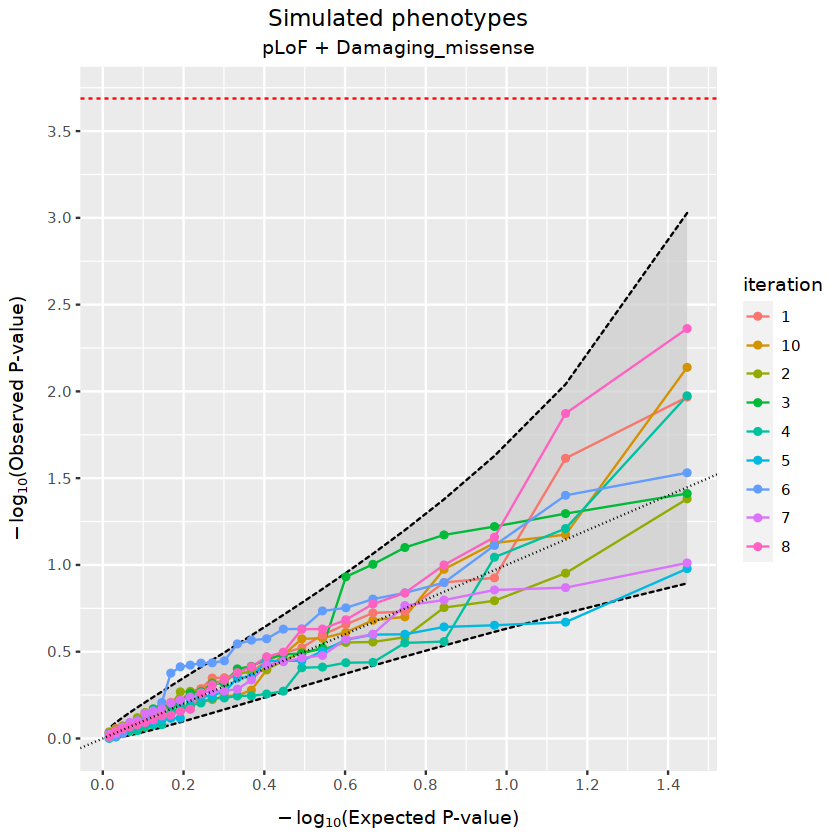

In [39]:
bonf <- 0.05 / (length(unique(d$ensembl_gene_id)) * length(unique(d$iteration)))
ggplot(d, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, color = iteration)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_line() +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    geom_hline(yintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    ggtitle("Simulated phenotypes", "pLoF + Damaging_missense") +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5),
          plot.subtitle = element_text(hjust=0.5))

In [64]:
args <- list(
    covars_keep ="sex,age,ukbb.centre,PC1,PC2,PC3,PC4",
    delimiter = "\t",
    input_path = "data/simulation/phenotypes/ukb_eur_h2_0.0_0.1_pi_0.0_0.010_K_0.1_chr21",
    output_path = "data/simulation/phenotypes/ukb_eur_h2_0.0_0.1_pi_0.0_0.010_K_0.1_chr21_phenos.tsv.gz",
    real_phenotype_path = "data/phenotypes/filtered_covar_phenotypes_cts.tsv.gz"
)

In [65]:
 print(args)
  stopifnot(dir.exists(dirname(args$input_path)))
  stopifnot(file.exists(args$real_phenotype_path))

  # load phenotypes and covariates to keep
  covars <- unlist(strsplit(args$covars_keep, split = ","))
  d <- fread(args$real_phenotype_path)
  d <- d[,colnames(d) %in% c("eid", covars), with = FALSE]
  stopifnot(ncol(d) > 0 )

  # load prefixes
  bname <- basename(args$input_path)
  dname <- dirname(args$input_path)
  files <- list.files(dname, pattern = bname, full.names = TRUE)
  if (length(files) == 0) stop(paste("no files with pattern",bname,"in directory",dname))
  files <- files[!grepl('_genes',files)]
  files <- files[!grepl('_phenos',files)]

  # merge prefixes
  lst <- lapply(files, function(f){
     id <- str_extract(basename(f),"[0-9]+.tsv.gz")
     id <- gsub('\\.tsv\\.gz','', id)
     d <- fread(f)
     colnames(d)[2:ncol(d)] <- paste0(colnames(d)[2:ncol(d)],'_', id)
     return(d)
  })



$covars_keep
[1] "sex,age,ukbb.centre,PC1,PC2,PC3,PC4"

$delimiter
[1] "\t"

$input_path
[1] "data/simulation/phenotypes/ukb_eur_h2_0.0_0.1_pi_0.0_0.010_K_0.1_chr21"

$output_path
[1] "data/simulation/phenotypes/ukb_eur_h2_0.0_0.1_pi_0.0_0.010_K_0.1_chr21_phenos.tsv.gz"

$real_phenotype_path
[1] "data/phenotypes/filtered_covar_phenotypes_cts.tsv.gz"



In [66]:
# combine phentypes and each prefix file
reduced <- Reduce(merge, lst)

In [67]:
final <- merge(reduced, d, by.x = 's', by.y = 'eid', all.x = TRUE)

In [68]:


  # add missing covariates
  final$age2 <- final$age^2
  final$sex_age <- final$age * final$sex

In [69]:
head(final)

s,y_no_noise_snp_1,y_no_noise_ko_1,y_cts_1,y_bin_1,y_no_noise_snp_2,y_no_noise_ko_2,y_cts_2,y_bin_2,y_no_noise_snp_3,⋯,y_bin_5,sex,age,ukbb.centre,PC1,PC2,PC3,PC4,age2,sex_age
<int>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,⋯,<lgl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1000028,0,0,-0.51664,FALSE,0,0,-0.73666,FALSE,0,⋯,FALSE,0,45,11014,-11.34000,3.304250,1.000060,1.3574900,2025,0
1000034,0,0,0.47452,FALSE,0,0,-1.38110,FALSE,0,⋯,FALSE,0,61,11004,-7.59207,0.766548,1.658150,-7.8436400,3721,0
1000087,0,0,0.30367,FALSE,0,0,0.59344,FALSE,0,⋯,FALSE,1,65,11010,-11.36170,3.991620,0.390405,-0.5858250,4225,65
1000118,0,0,1.40420,TRUE,0,0,-0.84322,FALSE,0,⋯,FALSE,1,55,11012,-12.72040,5.578300,0.148950,0.0547908,3025,55
1000120,0,0,1.13650,FALSE,0,0,-0.79976,FALSE,0,⋯,FALSE,0,46,11021,-11.03550,0.427943,-2.903620,-0.5809690,2116,0
1000162,0,0,-1.31810,FALSE,0,0,-0.33206,FALSE,0,⋯,FALSE,1,45,11018,-11.43270,2.185500,-1.207680,2.1947400,2025,45


In [70]:
colSums(final)

s y_no_noise_snp_1  y_no_noise_ko_1          y_cts_1 
    6.211309e+11     0.000000e+00     0.000000e+00     1.974225e+02 
         y_bin_1 y_no_noise_snp_2  y_no_noise_ko_2          y_cts_2 
    1.772400e+04     0.000000e+00     0.000000e+00     3.841489e+02 
         y_bin_2 y_no_noise_snp_3  y_no_noise_ko_3          y_cts_3 
    1.765900e+04     0.000000e+00     0.000000e+00     1.625559e+02 
         y_bin_3 y_no_noise_snp_4  y_no_noise_ko_4          y_cts_4 
    1.770400e+04     0.000000e+00     0.000000e+00    -4.825374e+02 
         y_bin_4 y_no_noise_snp_5  y_no_noise_ko_5          y_cts_5 
    1.761300e+04     0.000000e+00     0.000000e+00    -4.242039e+02 
         y_bin_5              sex              age      ukbb.centre 
    1.778100e+04               NA               NA               NA 
             PC1              PC2              PC3              PC4 
              NA               NA               NA               NA 
            age2          sex_age 
              NA               NA